In [3]:
import tensorflow as tf
from keras import layers,models,preprocessing
import numpy as np
import os
import matplotlib.pyplot as plt


In [4]:
DATA_DIR="celebA"
IMG_HEIGHT=64
IMG_WIDTH=64
BATCH_SIZE=128
BUFFER_SIZE=60000

In [5]:
def load_image(image_path):
    image=tf.io.read_file(image_path)
    image=tf.image.decode_jpeg(image, channels=3)
    image=tf.image.resize(image, [IMG_HEIGHT,IMG_WIDTH])
    image=(image-127.5)/127.5
    return image

In [6]:
def load_dataset(data_dir):
    image_paths=[os.path.join(data_dir,img) for img in os.listdir(data_dir)]
    image_dataset=tf.data.Dataset.from_tensor_slices(image_paths)
    image_dataset=image_dataset.map(load_image,num_parallel_calls=tf.data.experimental.AUTOTUNE)
    image_dataset=image_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.experimental.AUTOTUNE)
    return image_dataset

In [7]:
train_dataset=load_dataset(DATA_DIR)

In [8]:
def build_generator():
    model = models.Sequential()
    model.add(layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256) # Убедитесь, что выходная форма такая
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same',
    use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 16, 16, 128)
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same',
    use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 32, 32, 64)
    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False,activation='tanh'))
    assert model.output_shape == (None, 64, 64, 3)
    return model


In [9]:
def build_discriminator():
    model = models.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[64, 64, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [11]:
generator=build_generator()
discriminator=build_discriminator()
cross_entropy =tf._losses.BinaryCrossentropy(from_logits=True)

In [12]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [13]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [14]:
generator_optimizer = tf._optimizers.Adam(1e-4)
discriminator_optimizer = tf._optimizers.Adam(1e-4)

In [15]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
        gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
        generator_optimizer.apply_gradients(zip(gradients_of_generator,
        generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,
        discriminator.trainable_variables))

In [18]:
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        print(f'Эпоха {epoch + 1} завершена')
        if (epoch + 1) % 10 == 0:
            noise = tf.random.normal([16, 100])
            generate_and_save_images(generator, epoch + 1, noise)

In [19]:
EPOCHS = 1
train(train_dataset, EPOCHS)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Эпоха 1 завершена


In [17]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i] * 127.5 + 127.5).numpy().astype(np.uint8))
        plt.axis('off')
        plt.savefig(f'image_at_epoch_{epoch:04d}.png')
        plt.show()

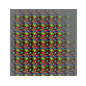

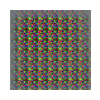

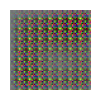

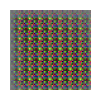

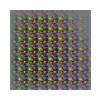

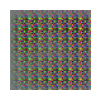

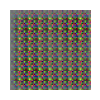

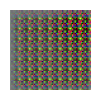

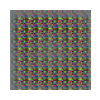

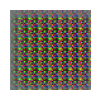

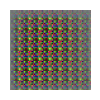

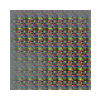

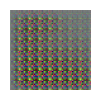

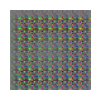

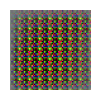

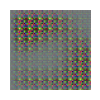

In [20]:
noise = tf.random.normal([16, 100])
generate_and_save_images(generator, EPOCHS, noise)